In [ ]:
# imports
from typing import Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

In [10]:
x = torch.randn(2, 2, 2)
print(x)

tensor([[[-0.4872,  0.3410],
         [ 0.1945, -0.9217]],

        [[-0.7783,  0.3495],
         [ 1.3779, -0.2704]]])


In [13]:
np_x = x.numpy()
np_x[0, 0, 0] = 0
print(np_x)

[[[ 0.          0.34101623]
  [ 0.1944618  -0.9217448 ]]

 [[-0.7783456   0.34947032]
  [ 1.3779325  -0.2704128 ]]]


In [ ]:
# make a random 3D tensor (5x4x4)
T = torch.randn(5, 4, 4)
print(T)

# get a specific element
print(T[0, 1, 3])

# get the 1st 4x4 matrix
f = T[0, :, :]
print(f)

# alternatively, you can use an ellipsis
print(T[0, ...] == f)

In [16]:
# sequential code
x = torch.randn(10)  # a random 1D tensor for this example
y1 = torch.zeros_like(x)  # this makes a tensor of zeros of the same shape as x
for i in range(len(x)):
    y1[i] = torch.sin(x[i])

In [17]:
# parallel code
y2 = torch.sin(x)  # we can pass a whole tensor into the torch.sin function!

# check to see they're equal
print(torch.equal(y1, y2))

True


In [21]:
# make the input tensor - 1K samples of 16x16 matrices
input_matrices = torch.randn(1000, 16, 16)
output_matrices = torch.fft.fft2(input_matrices)

In [22]:
print(f"Input Data Type: {input_matrices.dtype}")
print(f"Output Data Type: {output_matrices.dtype}")

Input Data Type: torch.float32
Output Data Type: torch.complex64


In [23]:
# note that we cannot simply call the .flatten() function here, because we need to preserve the index/batch dimension
num_samples = input_matrices.shape[0]  # should be 1K
# a value of -1 in the reshape function means "infer the size of this dimension based on the others". In this case, the effect is to flatten each individual matrix into a 1D vector
input_matrices = input_matrices.reshape(num_samples, -1)
output_matrices = output_matrices.reshape(num_samples, -1)
output_matrices = torch.cat(
    (output_matrices.real, output_matrices.imag), dim=-1
)  # this extra step is required to concatenate the real and imaginary parts along the embedding dimension

# check shapes
print(f"Input Shape: {input_matrices.shape}")
print(f"Output Shape: {output_matrices.shape}")

Input Shape: torch.Size([1000, 256])
Output Shape: torch.Size([1000, 512])


In [24]:
# save our data to disk so we don't have to regenerate it each time.
torch.save(input_matrices, "inputs.pt")
torch.save(output_matrices, "outputs.pt")

In [25]:
class FourierTransformDataset(Dataset):
    def __init__(
        self,
        input_filename: str,
        output_filename: str,
        indices: Tuple[int, int],
        transform=None,
        target_transform=None,
    ):
        # indices should be of form (start_index, end_index)
        start_index = indices[0]
        end_index = indices[1]

        self.inputs = torch.load(input_filename, weights_only=True)[
            start_index:end_index
        ]
        self.outputs = torch.load(output_filename, weights_only=True)[
            start_index:end_index
        ]

        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return self.inputs.shape[0]

    def __getitem__(self, index):
        input_matrix = self.inputs[index]
        output_matrix = self.outputs[index]

        # apply transformations (this will become very important later on!)
        if self.transform:
            input_matrix = self.transform(input_matrix)
        if self.target_transform:
            output_matrix = self.target_transform(output_matrix)

        return input_matrix, output_matrix

In [26]:
sample_dataset = FourierTransformDataset(
    input_filename="inputs.pt",
    output_filename="outputs.pt",
    indices=(0, 10),  # this is just a toy example
)
toy_dataloader = DataLoader(sample_dataset, batch_size=5, shuffle=True)

In [27]:
inputs, outputs = next(iter(toy_dataloader))
print(f"Input batch shape: {inputs.shape}")
print(f"Output batch shape: {outputs.size()}")

Input batch shape: torch.Size([5, 256])
Output batch shape: torch.Size([5, 512])


In [28]:
class FourierTransformModel(nn.Module):
    def __init__(self, input_dim=256, output_dim=512, dim_feedforward=1024):
        super().__init__()
        self.MLP = nn.Sequential(
            nn.Linear(input_dim, dim_feedforward),
            nn.GELU(),
            nn.Linear(dim_feedforward, dim_feedforward),
            nn.GELU(),
            nn.Linear(dim_feedforward, output_dim),
        )

    def forward(self, x):
        return self.MLP(x)

In [29]:
test_model = FourierTransformModel()
X = torch.randn(10, 256)
y = test_model(X)
print(y.shape)  # should be (10, 512)

torch.Size([10, 512])


In [30]:
# load the data
input_data = torch.load("inputs.pt", weights_only=True)
output_data = torch.load("outputs.pt", weights_only=True)

print(input_data.shape)
print(output_data.shape)

torch.Size([1000, 256])
torch.Size([1000, 512])


In [31]:
# a good split is 80% train, 20% test
x_mean = torch.mean(input_data[:800])
x_std = torch.std(input_data[:800])
print(f"Inputs Mean: {x_mean} || Inputs Standard Deviation: {x_std}")

# normalization constants must be computed for the inputs and outputs separately
y_mean = torch.mean(output_data[:800])
y_std = torch.std(output_data[:800])
print(f"Outputs Mean: {y_mean} || Outputs Standard Deviation: {y_std}")

Inputs Mean: -0.001063483185134828 || Inputs Standard Deviation: 1.0007257461547852
Outputs Mean: 0.0347176194190979 || Outputs Standard Deviation: 11.321858406066895


In [32]:
def normalize(x, mean, std_dev):
    return (x - mean) / std_dev


def denormalize(x, mean, std_dev):
    return (x * std_dev) + mean

In [33]:
train_dataset = FourierTransformDataset(
    "inputs.pt",
    "outputs.pt",
    indices=(0, 800),
    transform=lambda x: normalize(x, x_mean, x_std),
    target_transform=lambda y: normalize(y, y_mean, y_std),
)

test_dataset = FourierTransformDataset(
    "inputs.pt",
    "outputs.pt",
    indices=(800, 1000),
    transform=lambda x: normalize(x, x_mean, x_std),
    target_transform=lambda y: normalize(y, y_mean, y_std),
)

In [34]:
test_batch_size = train_batch_size = (
    32  # number of samples per batch (could vary for the last batch)
)
train_dataloader = DataLoader(train_dataset, train_batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, test_batch_size, shuffle=True)

In [35]:
def train_loop(dataloader, model, loss_fn, optimizer):
    training_loss = 0
    num_batches = len(dataloader)

    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        training_loss += loss.item()

    # get average
    training_loss /= num_batches
    print(f"Training Loss: {training_loss}")
    return training_loss


def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    num_batches = len(dataloader)
    test_loss = 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()

    test_loss /= num_batches
    print(f"Test Loss: {test_loss}\n")
    return test_loss

In [36]:
model = FourierTransformModel()
model.eval()

FourierTransformModel(
  (MLP): Sequential(
    (0): Linear(in_features=256, out_features=1024, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=1024, out_features=1024, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=1024, out_features=512, bias=True)
  )
)

In [38]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

In [39]:
train_losses = []
test_losses = []

epochs = 30
for t in range(epochs):
    print(f"Epoch {t + 1}\n-------------------------------")
    train_losses.append(train_loop(train_dataloader, model, loss_fn, optimizer))
    test_losses.append(test_loop(test_dataloader, model, loss_fn))
print("Done!")

Epoch 1
-------------------------------
Training Loss: 0.9770188593864441
Test Loss: 0.9436818531581334

Epoch 2
-------------------------------
Training Loss: 0.8708955669403076
Test Loss: 0.8488538776125226

Epoch 3
-------------------------------
Training Loss: 0.6891270875930786
Test Loss: 0.7145757590021405

Epoch 4
-------------------------------
Training Loss: 0.5016465032100678
Test Loss: 0.6030007771083287

Epoch 5
-------------------------------
Training Loss: 0.3822751259803772
Test Loss: 0.5272110785756793

Epoch 6
-------------------------------
Training Loss: 0.303156191110611
Test Loss: 0.4677731522492

Epoch 7
-------------------------------
Training Loss: 0.24614585161209107
Test Loss: 0.41968139580317904

Epoch 8
-------------------------------
Training Loss: 0.20456063687801362
Test Loss: 0.38358547006334576

Epoch 9
-------------------------------
Training Loss: 0.17133431255817413
Test Loss: 0.35192522406578064

Epoch 10
-------------------------------
Training Los

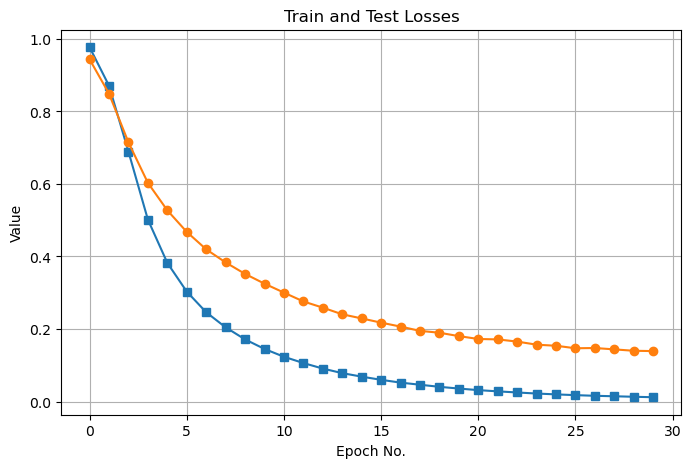

In [40]:
def plot_losses(train_losses, test_losses):
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, marker="s")  # Plot the list with markers
    plt.plot(test_losses, marker="o")  # Plot the list with markers
    plt.title("Train and Test Losses")
    plt.xlabel("Epoch No.")
    plt.ylabel("Value")
    plt.grid(True)

    # Show the plot
    plt.show()


plot_losses(train_losses, test_losses)

In [41]:
def reformat_matrix(tensor: torch.Tensor) -> torch.Tensor:
    # tensor should be a 1D vector of length 512
    real_part = tensor[:256].reshape(16, 16)
    imag_part = tensor[256:].reshape(16, 16)

    # return in complex form
    return torch.complex(real_part, imag_part)


# Just to make sure the function is correct, we can try on some sample data
x = torch.complex(torch.randn(16, 16), torch.randn(16, 16))
y = torch.cat((x.real.flatten(), x.imag.flatten()), dim=-1)
y = reformat_matrix(y)
print(torch.equal(x, y))  # should be True

True


In [42]:
def plot_complex_matrix(matrix):
    """
    Plots a complex-valued matrix. The real part is shown in one subplot,
    and the imaginary part is shown in another subplot.

    Args:
        matrix (torch.Tensor or np.ndarray): Complex-valued matrix to plot.
    """
    if isinstance(matrix, torch.Tensor):
        real_part = matrix.real.numpy()
        imag_part = matrix.imag.numpy()
    elif isinstance(matrix, np.ndarray):
        real_part = matrix.real
        imag_part = matrix.imag
    else:
        raise TypeError("Input must be a PyTorch tensor or a NumPy array.")

    plt.figure(figsize=(10, 5))

    # Plot the real part
    plt.subplot(1, 2, 1)
    plt.imshow(real_part, cmap="RdBu", interpolation="none")
    plt.colorbar()
    plt.title("Real Part")

    # Plot the imaginary part
    plt.subplot(1, 2, 2)
    plt.imshow(imag_part, cmap="BrBG", interpolation="none")
    plt.colorbar()
    plt.title("Imaginary Part")

    plt.tight_layout()
    plt.show()

True outputs


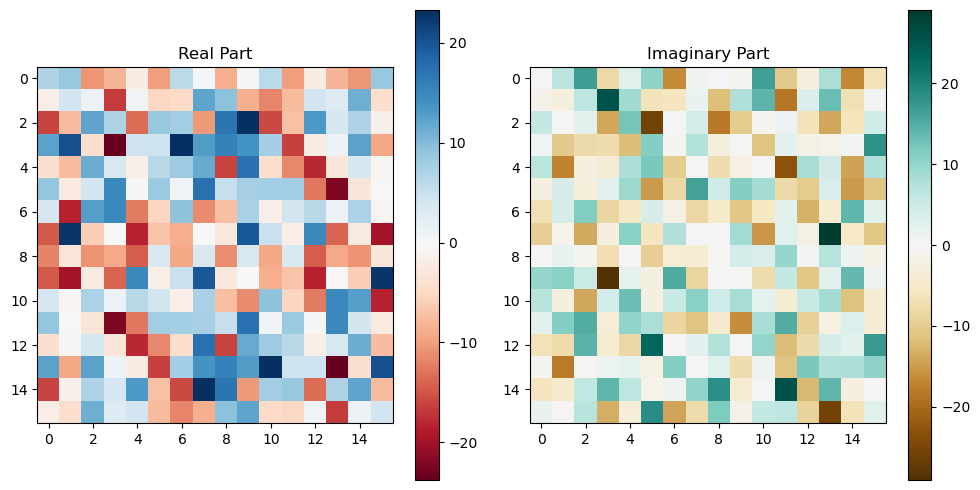

Model predictions


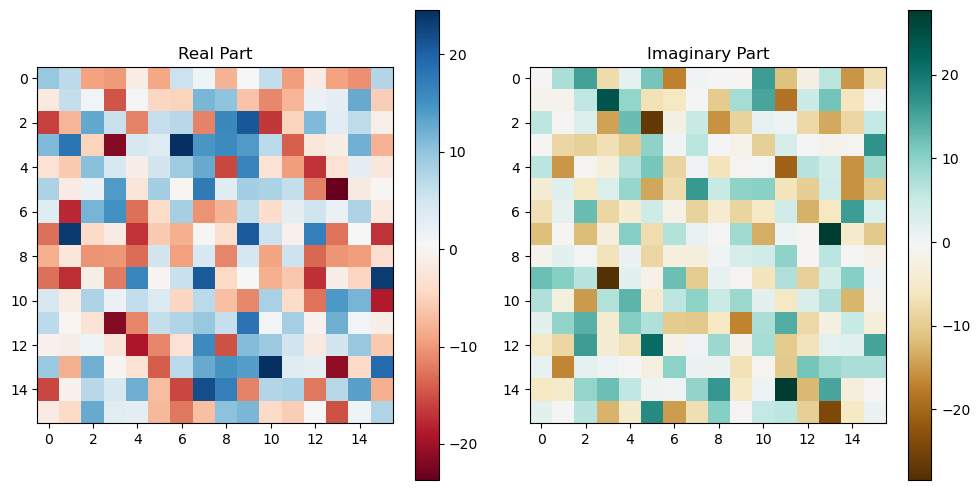

In [45]:
# input vector
x = inputs[-1]

# get true output
y = reformat_matrix(outputs[-1])

# plot the matrix
print("True outputs")
plot_complex_matrix(y)

# plot the matrix
print("Model predictions")
plot_complex_matrix(pred)

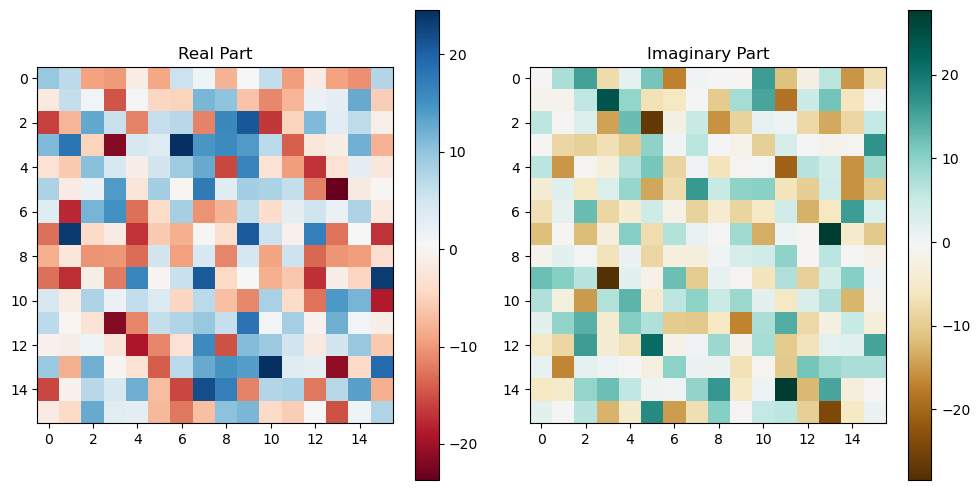

In [44]:
# get model predictions
with torch.no_grad():
    pred = model(x)

# post-processing
pred = reformat_matrix(pred)
pred = denormalize(pred, y_mean, y_std)

# plot the matrix
plot_complex_matrix(pred)